#**Projet ML — Classification Supervisée**
## Dataset : Breast Cancer Wisconsin
### Algorithmes testés : Decision Tree, Random Forest, Logistic Regression, KNN, SVM, AdaBoost
### `Bayane TOUKI | Licence ISI`

##**1 Importation des bibliothèques**

In [1]:
# Manipulation des données
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset
from sklearn.datasets import load_breast_cancer

# Prétraitement
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler

# ---- Les 6 Algorithmes ----
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Métriques d'évaluation
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

##**2 Chargement du Dataset**

In [2]:
data = load_breast_cancer()

df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

print("Dimensions du dataset :", df.shape)
print("\n Premières lignes :")
df.head()

Dimensions du dataset : (569, 31)

 Premières lignes :


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


##**3 Préparation des Données**

In [5]:
# Séparation features (X) et label (y)
X = df.drop('target', axis=1)
y = df['target']

# Split : 80% train, 20% test, random_state pour reproductibilité
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Normalisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Taille Train : {X_train.shape[0]} échantillons")
print(f"Taille Test  : {X_test.shape[0]} échantillons")
print(f"Nombre de features : {X_train.shape[1]}")

Taille Train : 455 échantillons
Taille Test  : 114 échantillons
Nombre de features : 30


In [6]:
results = {}

def evaluer_modele(nom, modele, X_tr, X_te, y_tr, y_te):
    """Entraîne, évalue et affiche les résultats d'un modèle."""

    # 1. Entraînement
    modele.fit(X_tr, y_tr)

    # 2. Prédiction
    y_pred = modele.predict(X_te)

    # 3. Métriques
    acc = accuracy_score(y_te, y_pred)
    cv  = cross_val_score(modele, X_tr, y_tr, cv=5).mean()

    # 4. Affichage
    print(f"\n{'='*50}")
    print(f" {nom}")
    print(f"{'='*50}")
    print(f"Accuracy (Test)       : {acc*100:.2f}%")
    print(f"Cross-Val (5-fold)    : {cv*100:.2f}%")
    print(f"\n Rapport de classification :")
    print(classification_report(y_te, y_pred,
          target_names=['Maligne', 'Bénigne']))

    # 5. Matrice de confusion
    cm = confusion_matrix(y_te, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Maligne', 'Bénigne'])
    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Matrice de Confusion — {nom}', fontsize=11)
    plt.tight_layout()
    plt.savefig(f'confusion_{nom.replace(" ", "_")}.png', dpi=150)
    plt.show()

    # 6. Sauvegarde dans le dictionnaire
    results[nom] = {'accuracy': acc, 'cross_val': cv}

    return modele

print("Fonction d'évaluation prête !")

Fonction d'évaluation prête !


##**4 Les six Algorithmes**


 Decision Tree
Accuracy (Test)       : 92.11%
Cross-Val (5-fold)    : 93.19%

 Rapport de classification :
              precision    recall  f1-score   support

     Maligne       0.87      0.93      0.90        42
     Bénigne       0.96      0.92      0.94        72

    accuracy                           0.92       114
   macro avg       0.91      0.92      0.92       114
weighted avg       0.92      0.92      0.92       114



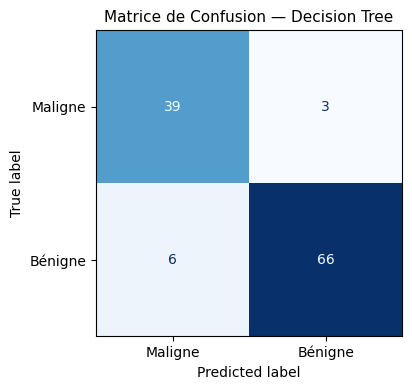

In [8]:
#1. DECISION TREE
dt = evaluer_modele(
    "Decision Tree",
    DecisionTreeClassifier(max_depth=5, random_state=42),
    X_train_scaled, X_test_scaled, y_train, y_test
)


 Random Forest
Accuracy (Test)       : 95.61%
Cross-Val (5-fold)    : 95.38%

 Rapport de classification :
              precision    recall  f1-score   support

     Maligne       0.95      0.93      0.94        42
     Bénigne       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



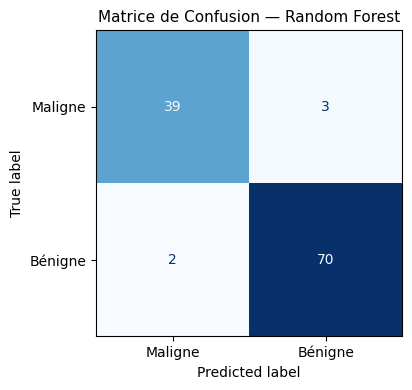

In [9]:
#2. RANDOM FOREST
rf = evaluer_modele(
    "Random Forest",
    RandomForestClassifier(n_estimators=100, random_state=42),
    X_train_scaled, X_test_scaled, y_train, y_test
)


 Logistic Regression
Accuracy (Test)       : 98.25%
Cross-Val (5-fold)    : 98.02%

 Rapport de classification :
              precision    recall  f1-score   support

     Maligne       0.98      0.98      0.98        42
     Bénigne       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



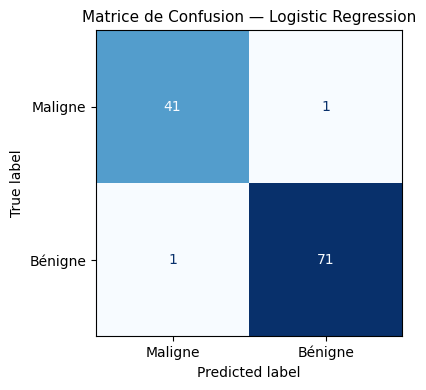

In [10]:
#3. LOGISTIC REGRESSION
lr = evaluer_modele(
    "Logistic Regression",
    LogisticRegression(max_iter=10000, random_state=42),
    X_train_scaled, X_test_scaled, y_train, y_test
)


 KNN (k=5)
Accuracy (Test)       : 95.61%
Cross-Val (5-fold)    : 96.70%

 Rapport de classification :
              precision    recall  f1-score   support

     Maligne       0.95      0.93      0.94        42
     Bénigne       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



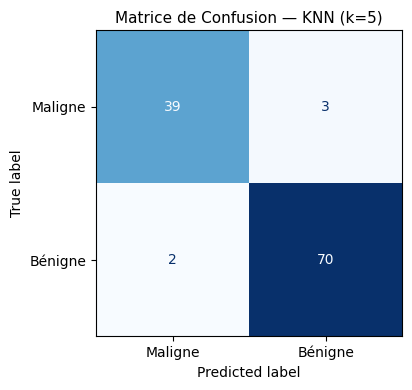

In [11]:
#4. K-NEAREST NEIGHBORS (K=5)
knn = evaluer_modele(
    "KNN (k=5)",
    KNeighborsClassifier(n_neighbors=5),
    X_train_scaled, X_test_scaled, y_train, y_test
)


 SVM Linéaire
Accuracy (Test)       : 97.37%
Cross-Val (5-fold)    : 96.70%

 Rapport de classification :
              precision    recall  f1-score   support

     Maligne       0.95      0.98      0.96        42
     Bénigne       0.99      0.97      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



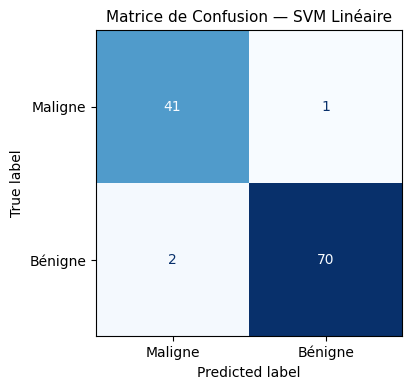

In [12]:
#5. SVM LINÉAIRE
svm = evaluer_modele(
    "SVM Linéaire",
    SVC(kernel='linear', random_state=42),
    X_train_scaled, X_test_scaled, y_train, y_test
)


 AdaBoost
Accuracy (Test)       : 95.61%
Cross-Val (5-fold)    : 97.36%

 Rapport de classification :
              precision    recall  f1-score   support

     Maligne       0.97      0.90      0.94        42
     Bénigne       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



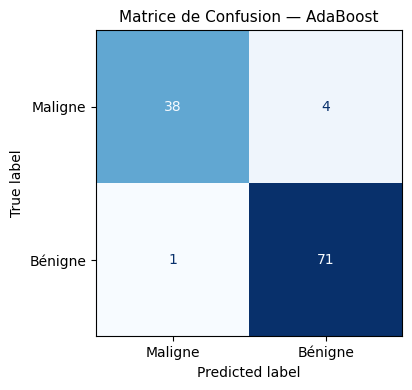

In [13]:
#6. ADABOOST
ada = evaluer_modele(
    "AdaBoost",
    AdaBoostClassifier(n_estimators=100, random_state=42),
    X_train_scaled, X_test_scaled, y_train, y_test
)

##**5 Comparaison final des 6 modèles**

CLASSEMENT DES MODÈLES :
                     Accuracy (%)  Cross-Val (%)
Logistic Regression         98.25          98.02
SVM Linéaire                97.37          96.70
KNN (k=5)                   95.61          96.70
Random Forest               95.61          95.38
AdaBoost                    95.61          97.36
Decision Tree               92.11          93.19


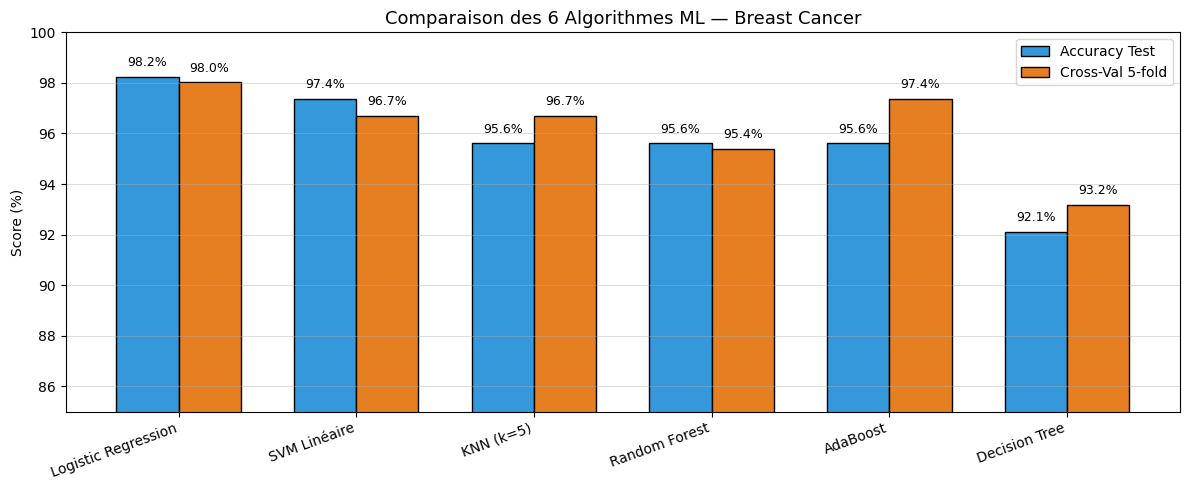

In [14]:
#COMPARAISON FINALE DES 6 MODÈLES
resultats_df = pd.DataFrame(results).T.sort_values('accuracy', ascending=False)
resultats_df.columns = ['Accuracy (%)', 'Cross-Val (%)']
resultats_df = resultats_df * 100

print("CLASSEMENT DES MODÈLES :")
print(resultats_df.round(2).to_string())

# Graphique comparatif
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(resultats_df))
width = 0.35

bars1 = ax.bar(x - width/2, resultats_df['Accuracy (%)'],
               width, label='Accuracy Test', color='#3498db', edgecolor='black')
bars2 = ax.bar(x + width/2, resultats_df['Cross-Val (%)'],
               width, label='Cross-Val 5-fold', color='#e67e22', edgecolor='black')

# Ajouter les valeurs sur les barres
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(resultats_df.index, rotation=20, ha='right')
ax.set_ylim(85, 100)
ax.set_ylabel('Score (%)')
ax.set_title('Comparaison des 6 Algorithmes ML — Breast Cancer', fontsize=13)
ax.legend()
ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('comparaison_modeles.png', dpi=150)
plt.show()

##**6 IMPORTANCE DES FEATURES — Random Forest**

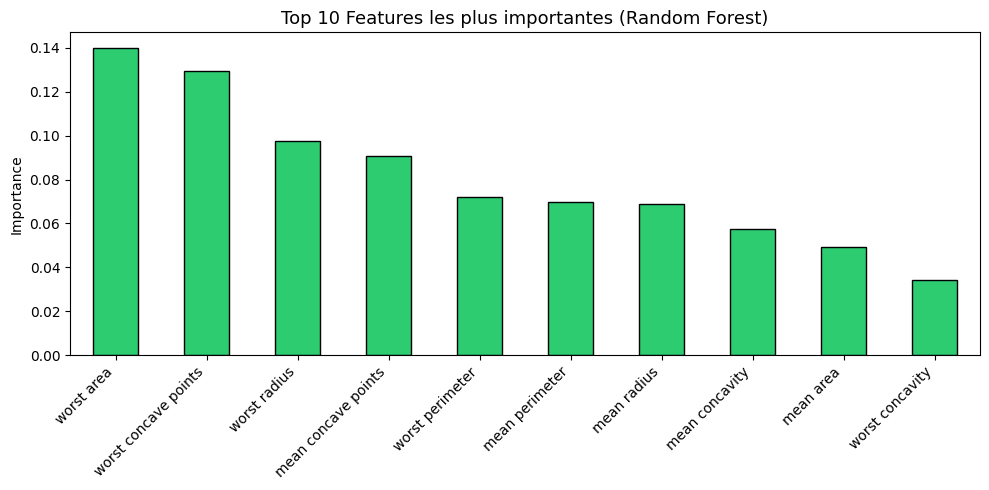

In [15]:
#Random Forest
importances = pd.Series(rf.feature_importances_, index=data.feature_names)
top10 = importances.sort_values(ascending=False)[:10]

plt.figure(figsize=(10, 5))
top10.plot(kind='bar', color='#2ecc71', edgecolor='black')
plt.title('Top 10 Features les plus importantes (Random Forest)', fontsize=13)
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()